In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
filePath = 'recentForm_data.csv'
df = pd.read_csv(filePath)
df

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,...,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts
0,2000-08-26,1.0,2.0,A,0.0,2.0,A,Andy D'Urso,14.0,9.0,...,0,0,0,0,0.0,4.0,0.0,1.0,3.0,0.0
1,2000-08-26,5.0,3.0,H,1.0,2.0,A,Steve Lodge,18.0,7.0,...,0,0,0,0,0.0,1.0,0.0,4.0,0.0,3.0
2,2000-08-26,1.0,0.0,H,0.0,0.0,D,Graham Poll,14.0,9.0,...,0,0,0,0,1.0,3.0,0.0,1.0,0.0,3.0
3,2000-08-26,0.0,0.0,D,0.0,0.0,D,Steve Bennett,8.0,13.0,...,0,0,0,0,0.0,1.0,0.0,0.0,0.0,1.0
4,2000-08-26,2.0,2.0,D,2.0,0.0,H,Mike Riley,12.0,7.0,...,0,0,0,0,0.0,2.0,0.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8641,2023-12-30,2.0,0.0,H,1.0,0.0,H,D Coote,18.0,4.0,...,0,0,0,0,1.6,1.6,6.0,0.4,2.0,4.0
8642,2023-12-31,3.0,1.0,H,1.0,0.0,H,S Hooper,12.0,24.0,...,0,0,0,0,2.4,1.4,10.0,2.6,1.0,13.0
8643,2023-12-31,2.0,1.0,H,1.0,1.0,D,J Smith,15.0,13.0,...,0,0,0,0,2.6,1.8,6.0,1.8,1.2,10.0
8644,2024-01-01,4.0,2.0,H,0.0,0.0,D,A Taylor,34.0,5.0,...,0,0,0,0,1.8,1.0,11.0,1.0,1.6,6.0


              precision    recall  f1-score   support

           0       0.54      0.55      0.55       853
           1       0.55      0.54      0.55       877

    accuracy                           0.55      1730
   macro avg       0.55      0.55      0.55      1730
weighted avg       0.55      0.55      0.55      1730



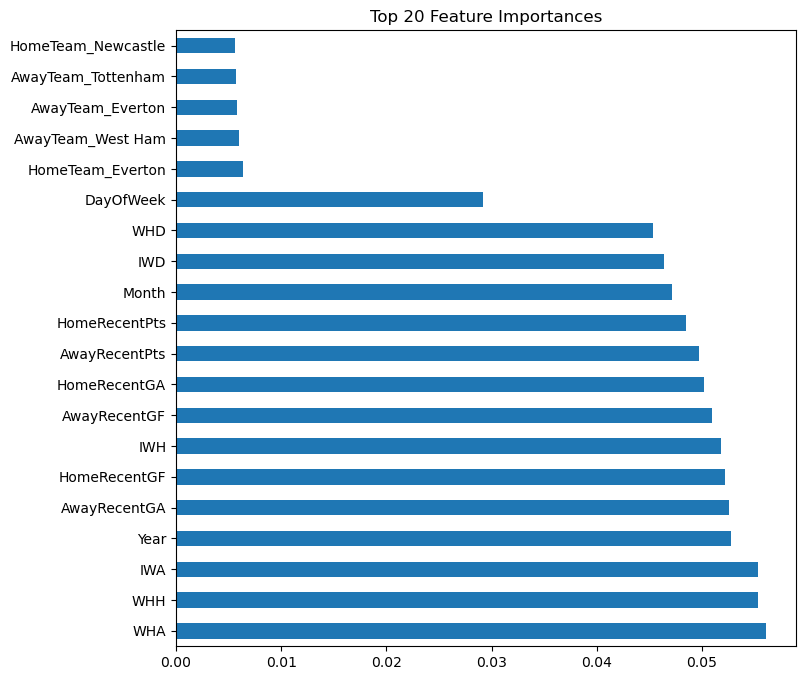

In [25]:
cols_to_drop = [
    # Target and outcome columns
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    # Half-time goals (outcome)
    'HTHG', 'HTAG',
    # Post-match/in-match stats (leakage!)
    'HS', 'AS', 'HST', 'AST',  # Shots, shots on target
    'HC', 'AC',                # Corners
    'HF', 'AF',                # Fouls
    'HY', 'AY',                # Yellow cards
    'HR', 'AR',                # Red cards
    # Encoded match result targets (one-hot)
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    # Raw result columns (if present)
    'FTR', 'HTR',
    # Team string columns (use one-hot or pre-match means instead)
    'HomeTeam', 'AwayTeam',
    # Date and Referee (optional: drop if not useful for your model)
    'Date', 'Referee'
]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['GoalsOver2_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances')
plt.show()

In [28]:
print(feat_importances)

IWH              0.051775
IWD              0.046344
IWA              0.055277
WHH              0.055340
WHD              0.045337
                   ...   
HomeRecentGA     0.050230
HomeRecentPts    0.048478
AwayRecentGF     0.050900
AwayRecentGA     0.052525
AwayRecentPts    0.049671
Length: 107, dtype: float64


In [29]:
feat_importances.to_string('feature_importances.txt')